# Segue 1


`propermotion = False` in `initialise_Seg1.py`, so there is no `sigma_PM,t` / `sigma_PM,R`
to plot and `sigp_k` replaces `sigp_prop_k`.


In [ ]:
#--- which object does gravsphere2 set up? ----------------------------------------------------
# gravsphere2.py now takes its initialise file from GS2_OBJECT instead of from
# whichever 'from initialise_* import *' line is uncommented in it, so this
# notebook no longer depends on the state of that file: working on the Leo II
# notebook can no longer leave this one restoring Output/LeoII/.
#
# This MUST run before 'from gravsphere2 import *' in the next cell. Python
# caches imported modules, so if gravsphere2 has already been imported in this
# kernel, changing it here does nothing until Kernel -> Restart.
import os
os.environ['GS2_OBJECT'] = 'Seg1'


In [1]:
#The gravsphere2 file defines the likelihood for sampling and opens the initialization file with the specific object
#with all the data, this is an example script doing some of the plots

#Our default example is for the Fornax LOS + PM simulation mock with 100 tracers

import os

os.environ['GS2_VARIANT'] = 'drop'      # 'keep' or 'drop'; MUST precede the import below

from gravsphere2 import *

import matplotlib.pyplot as plt

import dynesty
from dynesty import plotting as dyplot
from dynesty import DynamicNestedSampler

%matplotlib inline

[initialise_Seg1] variant = drop: N = 67 tracers from Seg1_Rproj_vlos_vloserr_drop.txt, individual = True, output -> Output/Segue1_drop/


In [2]:
#open sampling chain, in this case we open one that should have been already run (Fornax sim for 100 tracers + PMs)


diro = os.path.abspath(diro) + '/'      # 'Output/Segue1_drop/' from initialise_Seg1
resu = DynamicNestedSampler.restore(str(diro + 'Sampler Chains/segue1_chk')).results
assert np.isclose(resu["logl"][-1], lnprob(resu.samples[-1])), \
    'chain does not match GS2_VARIANT=%s' % variant
print(resu["logl"][-1], lnprob(resu.samples[-1]))


-182.4380628882713 -182.4380628882713


number of sampling iterations =  16256


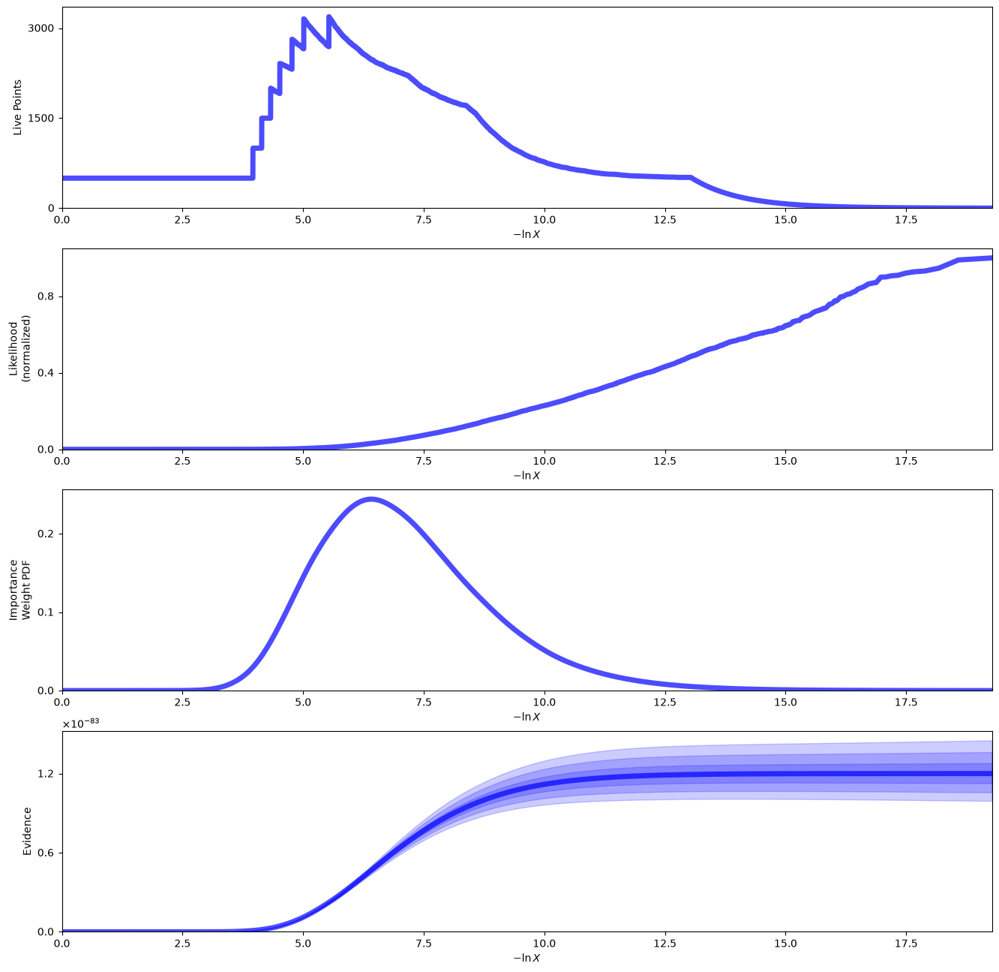

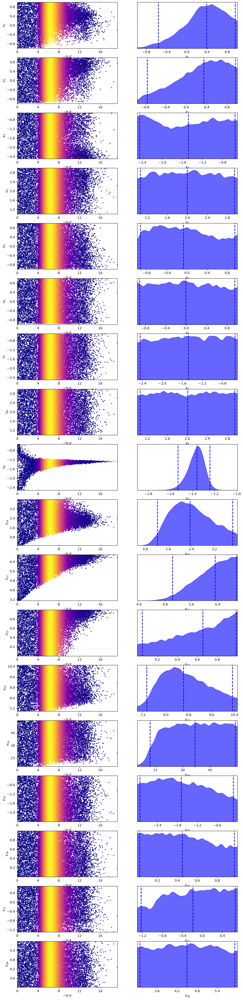

In [3]:
#diagnostic plot of the run, if the sampler has converged, the number of live points and weights should go to zero
#we can see this sampler has coverged correctly

print("number of sampling iterations = ", resu.niter)

from dynesty import plotting as dyplot

%matplotlib inline

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(resu)

# Plot traces and 1-D marginalized posteriors.
tfig, taxes = dyplot.traceplot(resu)

plt.show()

In [4]:
#--- Segue 1 setup: numbers from the run, radial grid, style helpers -------------------------

s1flat = resu.samples_equal()      # equal-weight posterior samples, shape (Nsamp, 18)


print('N tracers        = %d   (LOS only)' % len(rLOS))
print('R_proj range     = %.4f - %.4f kpc   (R_half = %.4f kpc)' % (rLOS.min(), rLOS.max(), Rhalf))
print('ndims            = %d' % ndims)
print('iterations       = %d,  calls = %d,  eff = %.2f%%'
      % (resu.niter, resu.ncall.sum(), 100*resu.niter/resu.ncall.sum()))
print('log Z            = %.3f +/- %.3f' % (resu.logz[-1], resu.logzerr[-1]))
print('max log L        = %.3f' % resu.logl.max())
print('equal-wt samples = %d' % len(s1flat))

# parameter order in Theta (individual == True, Mstar == 0, so ndims = 18)
s1labs = ['bet0_t', 'betinf_t', 'log rbeta', 'eta',            # 0-3  2nd-order anisotropy
          "bet0_t'", "betinf_t'", "log rbeta'", "eta'",        # 4-7  4th-order anisotropy
          'log rp', 'alp_p', 'bet_p', 'gam_p',                 # 8-11 tracer light profile
          'logM200', 'c200', 'log rc', 'n', 'log rt', 'delta'] # 12-17 coreNFWtides

print('\n%-11s %9s %9s %9s %9s   %s' % ('param', 'mean', '16%', '50%', '84%', 'prior'))
for i, l in enumerate(s1labs):
    mean = np.mean(s1flat[:, i])
    q = np.percentile(s1flat[:, i], [16, 50, 84])
    flag = ''
    if q[0] - minarr[i] < 0.05*(maxarr[i]-minarr[i]): flag += '  <- at lower prior edge'
    if maxarr[i] - q[2] < 0.05*(maxarr[i]-minarr[i]): flag += '  <- at upper prior edge'
    print('%-11s %9.3f %9.3f %9.3f %9.3f   [%.2f, %.2f]%s'
          % (l, mean, q[0], q[1], q[2], minarr[i], maxarr[i], flag))

#--- plotting setup --------------------------------------------------------------------------
col, al = 'mediumseagreen', 0.7
leg = r'Segue 1 (%d stars, LOS only)' % len(rLOS)
Rmax_dat = np.max(rLOS)                                  # outermost member, 90 pc
Ra = np.logspace(np.log10(1.0e-3), np.log10(0.3), 300)   # 1 pc - 300 pc
fsl = fst = 26*1.3

plt.style.use('default')
from matplotlib import rc
rc('axes', linewidth=1)
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
rc('font', weight='bold')


def band(samples_2d, levels=(0.0275, 0.16, 0.5, 0.84, 0.975)):
    """95%, 68% and median envelopes of an (Nsamp, Nr) array of profiles."""
    return np.percentile(samples_2d, 100*np.array(levels), axis=0)


def pretty_ax(ax, ylo, yhi, xlo=2e-3, xhi=0.2, logy=False):
    """Fornax-notebook axis styling, plus R_half and an 'outside the data' shading."""
    ax.axvline(Rhalf, ls='--', color='gray', lw=3.0, zorder=0)
    ax.axvspan(Rmax_dat, xhi, color='0.85', alpha=0.6, zorder=-5)   # no tracers out here
    ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.tick_params(labelsize=fst)
    ax.tick_params('both', length=8.5, width=2.5, which='major', direction='out')
    ax.tick_params('both', length=5, width=1.8, which='minor', direction='out')
    axx, axy = ax.secondary_yaxis('right'), ax.secondary_xaxis('top')
    for sec in (axx, axy):
        sec.tick_params('both', length=8.5, width=2.5, which='major', direction='in')
        sec.tick_params('both', length=5, width=1.8, which='minor', direction='in')
    axx.set_yticklabels([])
    axy.set_xticklabels([])
    for s in ['top', 'bottom', 'left', 'right']:
        ax.spines[s].set_linewidth(2.5)


N tracers        = 67   (LOS only)
R_proj range     = 0.0003 - 0.0903 kpc   (R_half = 0.0295 kpc)
ndims            = 18
iterations       = 16256,  calls = 431031,  eff = 3.77%
log Z            = -190.932 +/- 0.063
max log L        = -182.438
equal-wt samples = 16256

param            mean       16%       50%       84%   prior
bet0_t          0.347    -0.063     0.388     0.766   [-1.00, 1.00]
betinf_t        0.271    -0.258     0.342     0.775   [-1.00, 1.00]
log rbeta      -1.500    -2.223    -1.478    -0.804   [-2.50, -0.50]
eta             1.994     1.329     1.997     2.653   [1.00, 3.00]
bet0_t'        -0.046    -0.675    -0.074     0.613   [-1.00, 1.00]
betinf_t'       0.004    -0.645    -0.006     0.658   [-1.00, 1.00]
log rbeta'     -1.482    -2.156    -1.476    -0.813   [-2.50, -0.50]
eta'            2.005     1.331     2.004     2.687   [1.00, 3.00]
log rp         -1.368    -1.439    -1.361    -1.299   [-2.53, -0.53]
alp_p           2.415     1.667     2.347     3.216   [0.10

In [ ]:
# rc('text', usetex=True) above shells out to latex + dvipng. The texlive-core
# in the conda env is binaries only (no macros, no dvipng, so it cannot build
# latex.fmt) and it sits ahead of everything else on PATH, which is what raised
# "I can't find the format file `latex.fmt'". TinyTeX in $HOME is the working
# install, so put it first.
import os
_texbin = os.path.expanduser('~/.TinyTeX/bin/x86_64-linux')
if not os.environ['PATH'].startswith(_texbin):
    os.environ['PATH'] = _texbin + os.pathsep + os.environ['PATH']


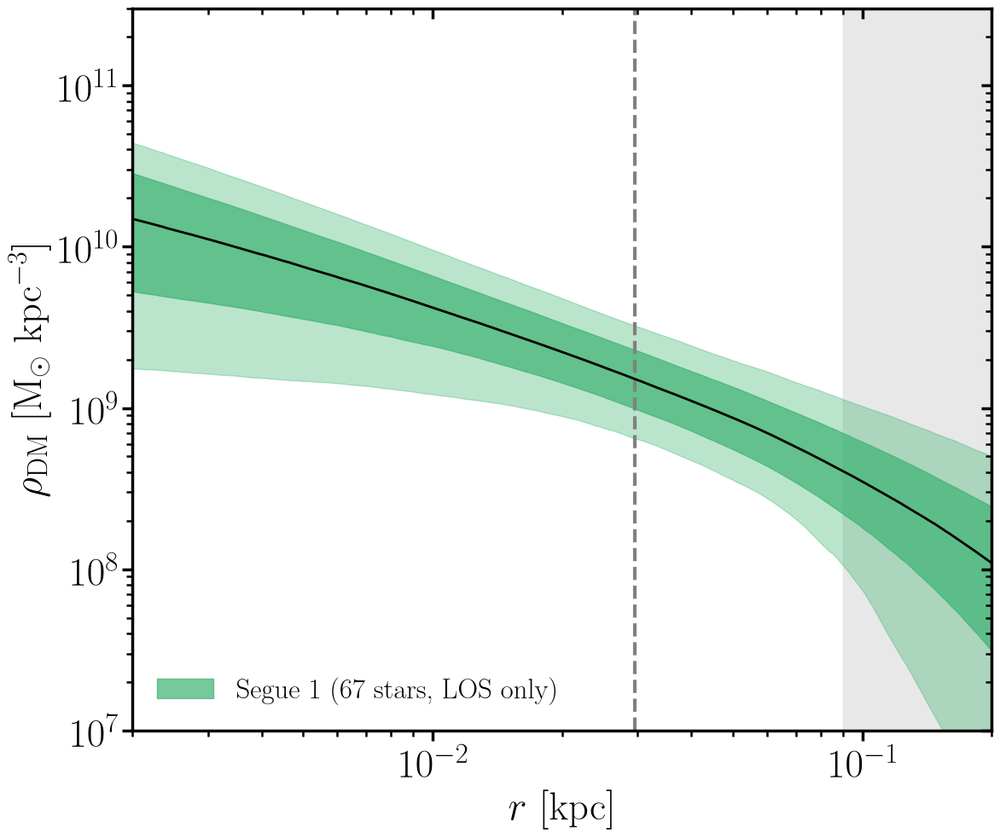

log10 rho_DM(R_half) = 9.18 -0.19 +0.18  [Msun/kpc^3]


In [5]:
#--- Segue 1: DM density profile -------------------------------------------------------------

upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:                    # exponentiate the log-sampled parameters
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]  # coreNFWtides
    upacs[k, :] = corenfw_tides_den(Ra, *Mppars)

b = band(upacs)

fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)   # 95%
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)  # 68%
ax.plot(Ra, b[2], color='k', lw=2.0)                               # median
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\rho_{\rm DM}$ [M$_{\odot}$ kpc$^{-3}$]', fontsize=fsl)
pretty_ax(ax, 1e7, 3e11, logy=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.savefig(str(diro + 'Plots/den_segue1.pdf'), bbox_inches='tight')
plt.show()

q = np.percentile(np.log10(upacs[:, np.argmin(np.abs(Ra - Rhalf))]), [16, 50, 84])
print('log10 rho_DM(R_half) = %.2f -%.2f +%.2f  [Msun/kpc^3]' % (q[1], q[1]-q[0], q[2]-q[1]))


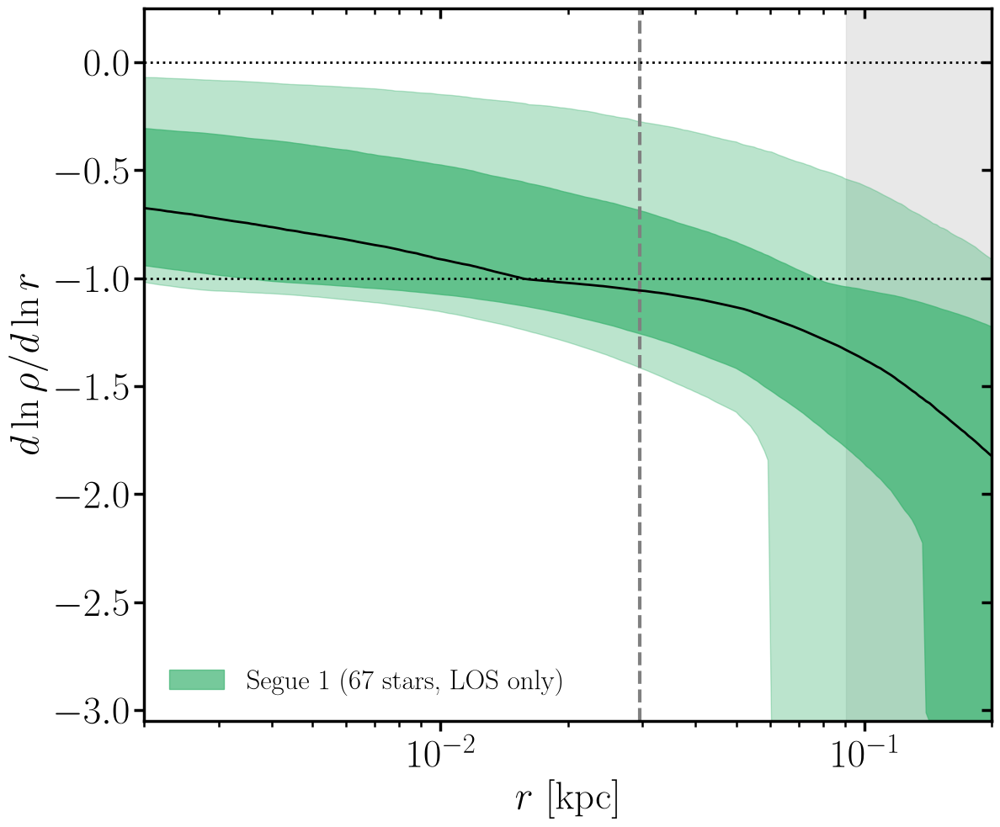

dlnrho/dlnr at r = 0.0074 kpc : -0.85 -0.20 +0.42
dlnrho/dlnr at r = 0.0147 kpc : -0.99 -0.13 +0.44
dlnrho/dlnr at r = 0.0295 kpc : -1.06 -0.20 +0.37


In [6]:
#--- Segue 1: logarithmic density slope (the cusp/core diagnostic) ----------------------------

upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]
    upacs[k, :] = corenfw_tides_dlnrhodlnr(Ra, *Mppars, dx=1e-5)

b = band(upacs)

fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(-1.0, ls=':', color='k', lw=2.0)      # NFW cusp
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # perfect core
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'${d \ln \rho} / {d \ln r}$', fontsize=fsl)
pretty_ax(ax, -3.05, 0.25)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.savefig(str(diro + 'Plots/slope_segue1.pdf'), bbox_inches='tight')
plt.show()

for rr in [Rhalf/4, Rhalf/2, Rhalf]:
    q = np.percentile(upacs[:, np.argmin(np.abs(Ra - rr))], [16, 50, 84])
    print('dlnrho/dlnr at r = %.4f kpc : %.2f -%.2f +%.2f' % (rr, q[1], q[1]-q[0], q[2]-q[1]))


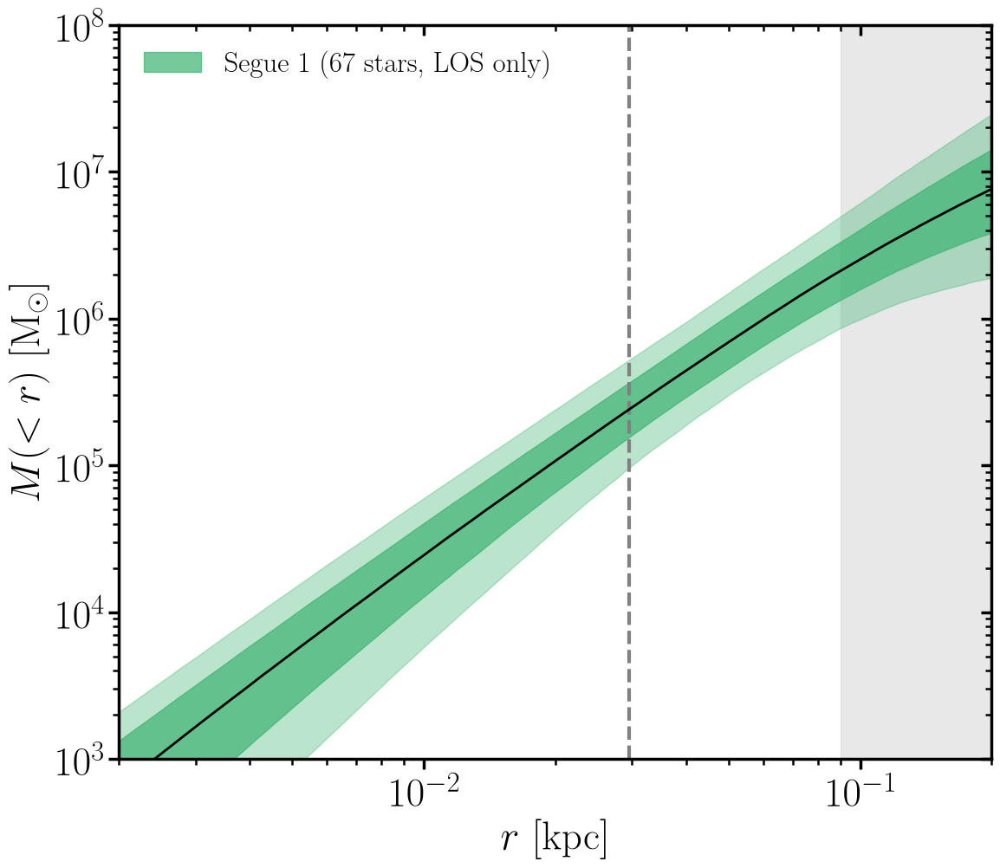

log10 M(<R_half) = 5.37 -0.19 +0.18  [Msun]


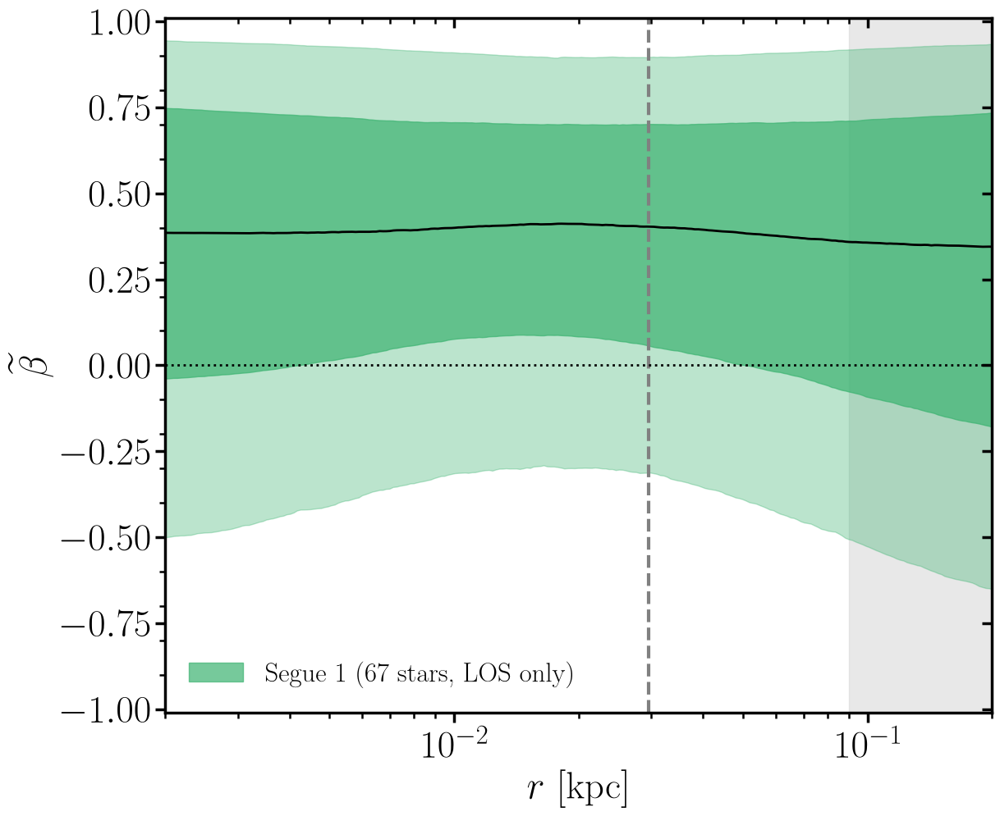

betat(R_half) = 0.40 -0.35 +0.30


In [7]:
#--- Segue 1: enclosed mass, and the symmetrised anisotropy -----------------------------------

# enclosed mass
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]
    upacs[k, :] = corenfw_tides_mass(Ra, *Mppars)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$M(<r)$ [M$_{\odot}$]', fontsize=fsl)
pretty_ax(ax, 1e3, 1e8, logy=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='upper left')
plt.savefig(str(diro + 'Plots/mass_segue1.pdf'), bbox_inches='tight')
plt.show()

q = np.percentile(np.log10(upacs[:, np.argmin(np.abs(Ra - Rhalf))]), [16, 50, 84])
print('log10 M(<R_half) = %.2f -%.2f +%.2f  [Msun]' % (q[1], q[1]-q[0], q[2]-q[1]))

# symmetrised anisotropy  betat = beta / (2 - beta)
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.savefig(str(diro + 'Plots/ani_segue1.pdf'), bbox_inches='tight')
plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))


In [8]:
#--- Segue 1: projected sigma_LOS and kurtosis (LOS only -> sigp_k, not sigp_prop_k) ----------
# ~0.12 s per sample, so 500 samples is about a minute. Results are cached to disk.

nls = 500        # number of random posterior draws; raise for smoother envelopes
s1file = 'segue1'

upacsl = np.zeros((nls, len(Ra)))    # sigma_LOS
upacslk = np.zeros((nls, len(Ra)))   # kappa_LOS

for it in range(nls):
    theta = np.copy(s1flat[np.random.randint(len(s1flat))])

    # symmetrised -> ordinary anisotropy, 2nd and 4th order
    theta[0] = 2.0*theta[0]/(1 + theta[0])
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    theta[4] = 2.0*theta[4]/(1 + theta[4])
    theta[5] = 2.0*theta[5]/(1 + theta[5])
    for i in logthis:
        theta[i] = 10**theta[i]

    surc = theta[2*n_betpars:2*n_betpars+nu_components]     # tracer light profile
    if individual == True:
        surc = np.append(np.array([1.0]), surc)             # rho0 is unconstrained, set to 1

    rhobs = alpbetgamden(nu_rad, *surc)
    sobs = alpbetgamsurf(nu_rad, *surc, bar_pnts)

    def baranr(r):                                          # tracer 3D density
        return np.interp(r, nu_rad, rhobs, right=1e-30)

    def barsurf(r):                                         # tracer 2D density
        return np.interp(r, nu_rad, sobs, right=1e-30)

    Mpars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]

    def M(r, Mparsu):                                       # Mstar = 0 for Segue 1
        M200, c, rc, n, rt, delta = Mparsu
        return corenfw_tides_mass(r, M200, c, rc, n, rt, delta)

    Sigout, los2, kl, neg = sigp_k(np.array([1.0]), Ra, baranr, barsurf, M, beta, betaf,
                                   Mpars, theta[:4], theta[4:8], rmin, rmax, nonn=rcn)

    upacsl[it, :] = los2**0.5/1e3
    upacslk[it, :] = kl

np.savetxt(str(diro + s1file + '_sl.txt'), band(upacsl))
np.savetxt(str(diro + s1file + '_kl.txt'), band(upacslk))
print('done -> ' + diro + s1file + '_{sl,kl}.txt')


done -> /rds/general/user/jd925/home/PhD_first_year/GravSphere2/Output/Segue1_drop/segue1_{sl,kl}.txt


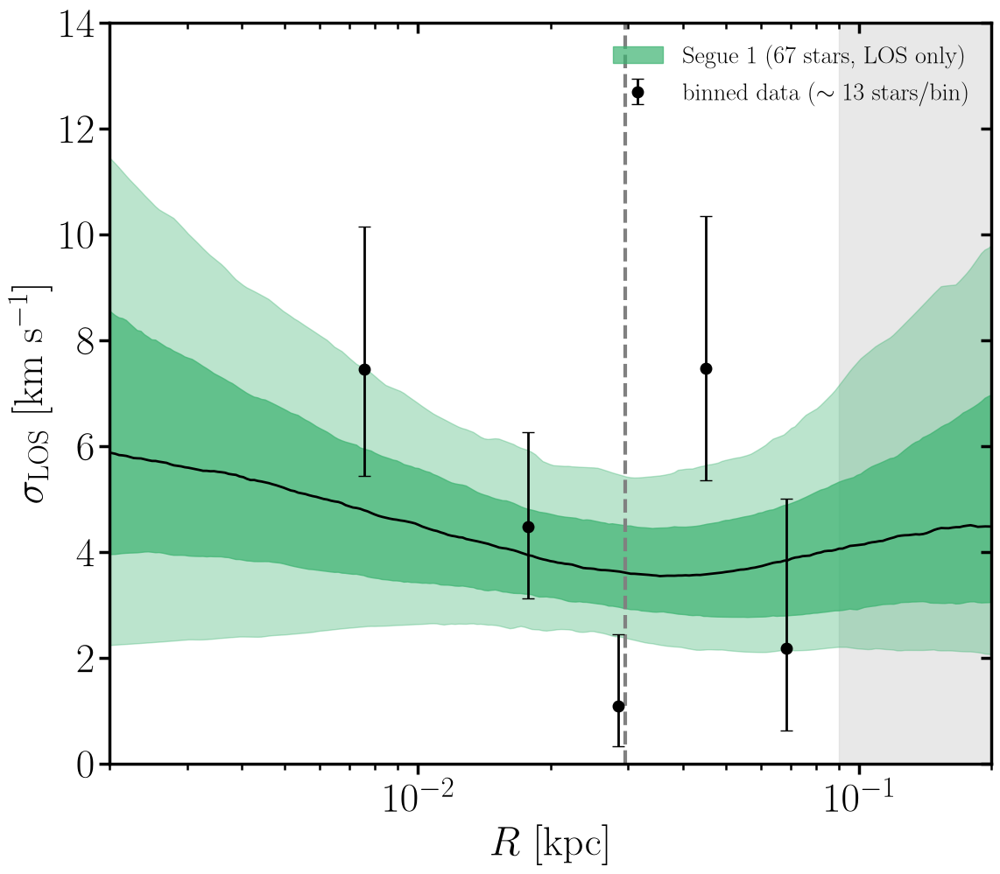

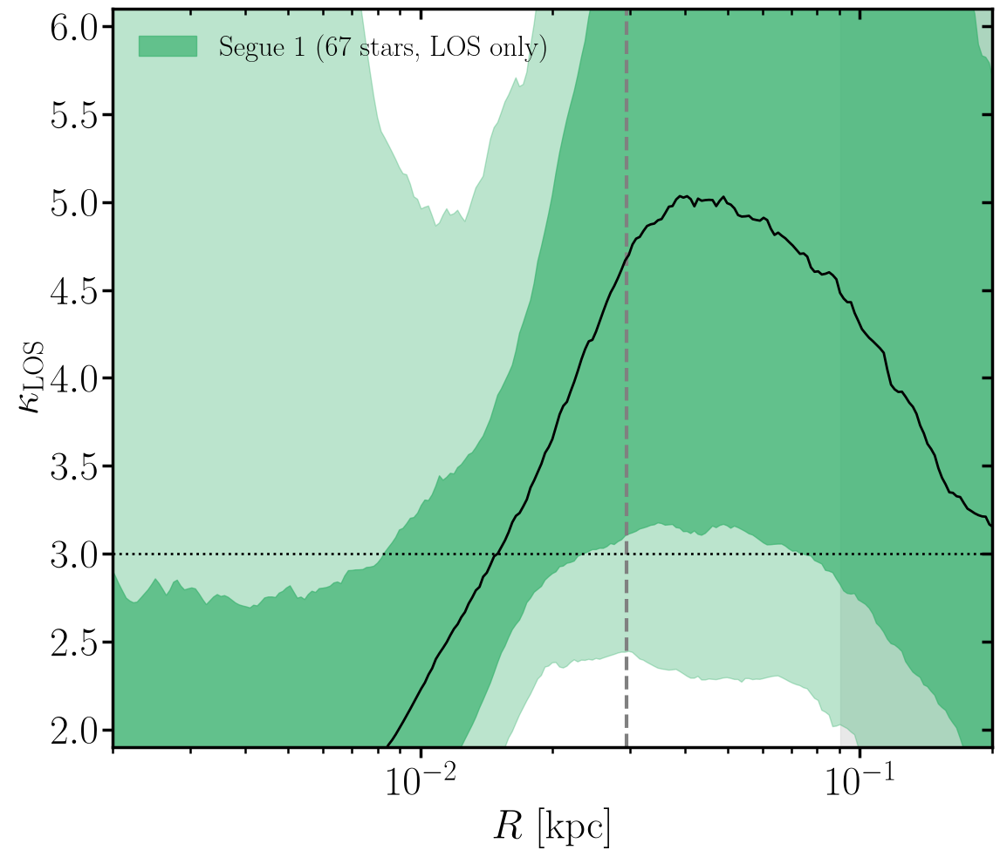

In [9]:
#--- Segue 1: sigma_LOS and kappa_LOS, with binned data over-plotted --------------------------
# The binned points are a *visual* check only. The fit itself is bin-free: it uses each star's
# own velocity + error. With errors of 2-38 km/s against an ~4 km/s dispersion, single bins are
# very noisy, so do not read a tension off one discrepant point.

nbin = 5
sgrid = np.linspace(0.05, 25.0, 600)


def sig_ml(v, e):
    """16/50/84 of sigma in one bin: Gaussian likelihood with per-star errors,
    systemic velocity profiled out on a grid (a plain moment estimate goes
    imaginary here because the errors exceed the dispersion)."""
    mug = np.linspace(v.min()-5, v.max()+5, 200)
    var = sgrid[:, None, None]**2 + e[None, None, :]**2
    d2 = (v[None, None, :] - mug[None, :, None])**2
    lnL = -0.5*np.sum(d2/var + np.log(2*np.pi*var), axis=2)
    L = np.exp(lnL - lnL.max()).sum(axis=1)
    return np.interp([0.16, 0.5, 0.84], np.cumsum(L)/np.sum(L), sgrid)


idx = np.argsort(rLOS)
Rs, vs, es = rLOS[idx], vLOS[idx], vLOS_err[idx]
groups = np.array_split(np.arange(len(Rs)), nbin)
Rb = np.array([Rs[g].mean() for g in groups])
qb = np.array([sig_ml(vs[g], es[g]) for g in groups])
sb = qb[:, 1]
sberr = np.vstack([sb - qb[:, 0], qb[:, 2] - sb])

# sigma_LOS
b = np.loadtxt(str(diro + s1file + '_sl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.errorbar(Rb, sb, yerr=sberr, fmt='o', color='k', ms=9, capsize=5, lw=2.0, zorder=5,
            label=r'binned data ($\sim %d$ stars/bin)' % (len(Rs)//nbin))
ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
pretty_ax(ax, 0.0, 14.0)
ax.legend(frameon=False, fontsize=fsl*0.6, loc='upper right')
plt.savefig(str(diro + 'Plots/sl_segue1.pdf'), bbox_inches='tight')
plt.show()

# kappa_LOS
b = np.loadtxt(str(diro + s1file + '_kl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(3.0, ls=':', color='k', lw=2.0)       # Gaussian
ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\kappa_{\rm LOS}$', fontsize=fsl)
pretty_ax(ax, 1.9, 6.1)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='upper left')
plt.savefig(str(diro + 'Plots/kl_segue1.pdf'), bbox_inches='tight')
plt.show()


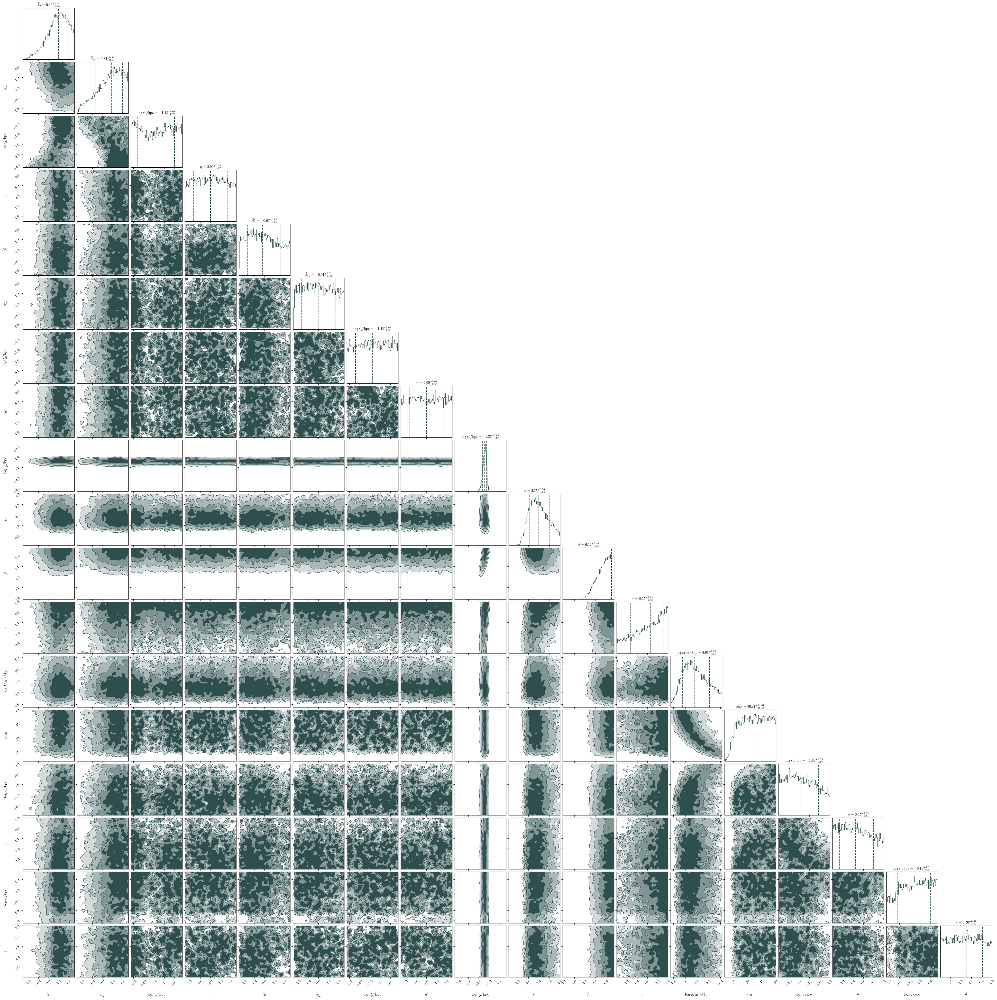

In [10]:
#--- Segue 1: corner plot --------------------------------------------------------------------

import corner

labes = [r'$\widetilde \beta_0$', r'$\widetilde \beta_{\infty}$',
         r'$\log r_{\beta}$/kpc', r'$\eta$',
         r"$\widetilde \beta_0'$", r"$\widetilde \beta_{\infty}'$",
         r"$\log r_{\beta}'$/kpc", r"$\eta'$",
         r'$\rho_{p}$/kpc$^{-3}$', r'$r_p$/kpc',
         r'$\alpha$', r'$\beta$', r'$\gamma$',
         r'$\log M_{200}$/M$_{\odot}$', r'$c_{200}$',
         r'$\log r_c$/kpc', r'$n$', r'$\log r_t$/kpc', r'$\delta$']

if individual == True:
    labes[9] = r'$\log r_p$/kpc'   # log-priors on rp in the individual-tracer case
    labes.pop(2*n_betpars)         # rho_p is not a free parameter, drop its label

levs = (1 - np.exp(-(1)**2/2), 1 - np.exp(-(1.5)**2/2),
        1 - np.exp(-(2.0)**2/2), 1 - np.exp(-(2.5)**2/2))

seq = resu.samples_equal()
if Mstar != 0.0:
    labes.append(r'$\log M_{\star}$ [M$_{\odot}$]')
    seq[:, -1] = np.log10(seq[:, -1])

fig = corner.corner(seq, labels=labes,
    quantiles=(0.16, 0.5, 0.84), label_kwargs=dict(fontsize=11),
    show_titles=True, title_fmt='.2f', use_math_text=True, title_kwargs=dict(fontsize=10),
    bins=70, smooth=1.4, fill_contours=True, color='darkslategray',
    plot_datapoints=False, plot_density=False,
    contour_kwargs={'linewidths': 0.8}, levels=levs,
    range=[(minarr[i], maxarr[i]) for i in range(ndims)])   # show the full prior box:
                                                            # flat-topped 1D panels = prior-limited

plt.savefig(str(diro + 'Plots/corner_segue1.pdf'), bbox_inches='tight')
plt.show()


# Plots for comparison with simulations

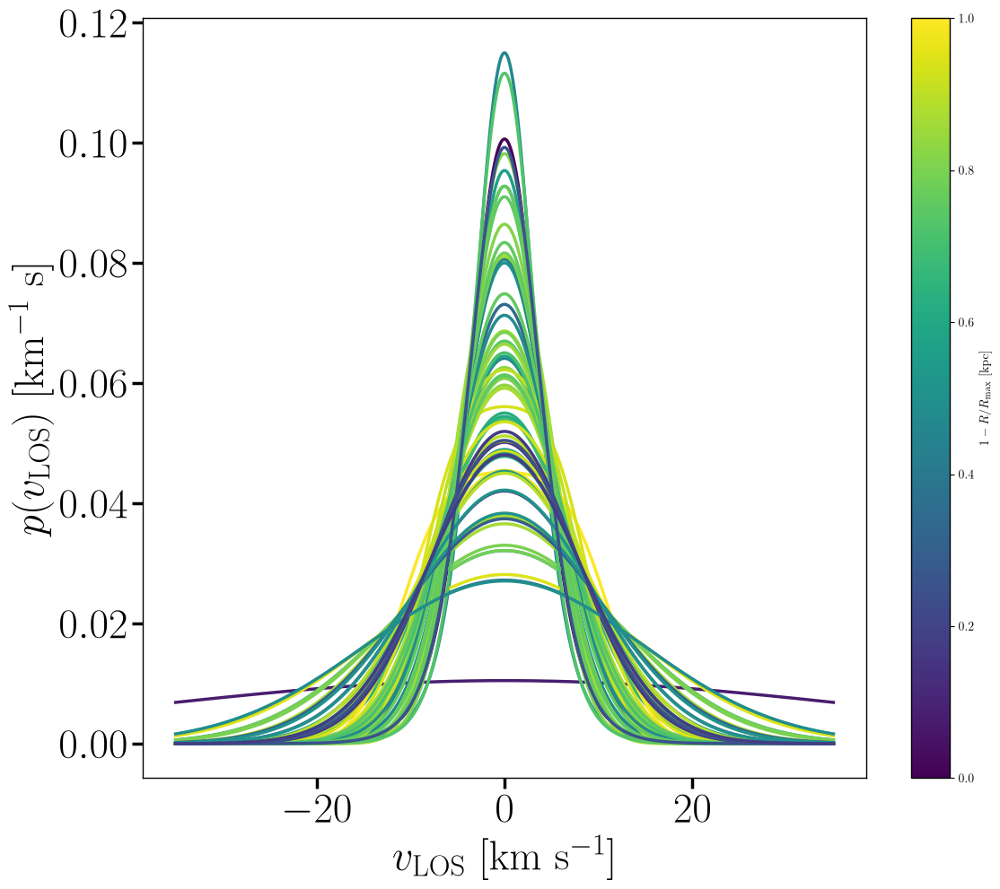

In [11]:
#--- Segue 1: LOS velocity distributions from Eqs. A.1 / A.6 ---------------------------------
from scipy.special import ndtr, erfc          # ndtr = Phi, the standard normal CDF (Eq. A.2)

aguess = np.linspace(1e-6, 100, 10**4)

def get_a(kurt):

    if kurt < 3.0:
        kg = 3.0 - (2*aguess**4/15)*(1 + aguess**2/3)**(-2.0)              # A.4
        return np.interp(kurt, kg[::-1], aguess[::-1])
    else:
        kg = 3.0 + 12*aguess**4*(2*aguess**2 + 1)**(-2.0)                      # A.7
        return np.interp(kurt, kg, aguess)

def fvel(v, sigma, kurt, err):
    
    w = np.asarray(v, dtype=float)/sigma
    s = err/sigma

    if abs(kurt - 3.0) < 1e-4:                                       # a -> 0: Gaussian limit
        t = np.sqrt(1.0 + s**2)
        return np.exp(-0.5*(w/t)**2)/(np.sqrt(2*np.pi)*t)/sigma
    
    a = get_a(kurt)
    if kurt < 3.0:
        b = np.sqrt(1.0 + a**2/3.0)                                  # A.5
        t = np.sqrt(1.0 + b**2*s**2)                                 # A.3
        f = b/(2*a)*(ndtr((b*w + a)/t) - ndtr((b*w - a)/t))          # A.1
    else:
        b = np.sqrt(2.0*a**2 + 1.0)                                  # A.8
        t = np.sqrt(1.0 + b**2*s**2)                                 # A.3
        f = b/(4*a)*(np.exp((t**2 - 2*a*b*w)/(2*a**2))*erfc((t**2 - a*b*w)/(np.sqrt(2)*t*a))
                   + np.exp((t**2 + 2*a*b*w)/(2*a**2))*erfc((t**2 + a*b*w)/(np.sqrt(2)*t*a)))  # A.6
    return f/sigma

n_prof = len(rLOS)
Rshow  = rLOS
R_max = np.max(Rshow)

sl     = np.loadtxt(str(diro + s1file + '_sl.txt'))[2]
kl     = np.loadtxt(str(diro + s1file + '_kl.txt'))[2]
sig_at = np.interp(Rshow, Ra, sl)
kur_at = np.interp(Rshow, Ra, kl)

star_data = np.loadtxt('/rds/general/user/jd925/home/PhD_first_year/GravSphere2/Data/Seg1/Seg1_Rproj_vlos_vloserr_drop.txt')

vLOS_err = star_data[:, 2]

vv = np.linspace(-35.0, 35.0, 1000)
fig, ax = plt.subplots(figsize=(13, 11))
for i, (R, s, k) in enumerate(zip(Rshow, sig_at, kur_at)):
    err = vLOS_err[i]
    ax.plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
            ls='-', label=r'$R = %.1f$ pc' % (1e3*R))
ax.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', label=r'$1 - R/R_{\max}$ [kpc]')
ax.set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
ax.set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=fsl)
ax.tick_params(labelsize=fst)
ax.tick_params('both', length=8.5, width=2.5, which='major', direction='out')
#ax.legend(frameon=False, fontsize=fsl*0.45, ncol=2)
plt.savefig(str(diro + 'Plots/vdf_segue1.pdf'), bbox_inches='tight')
plt.show()


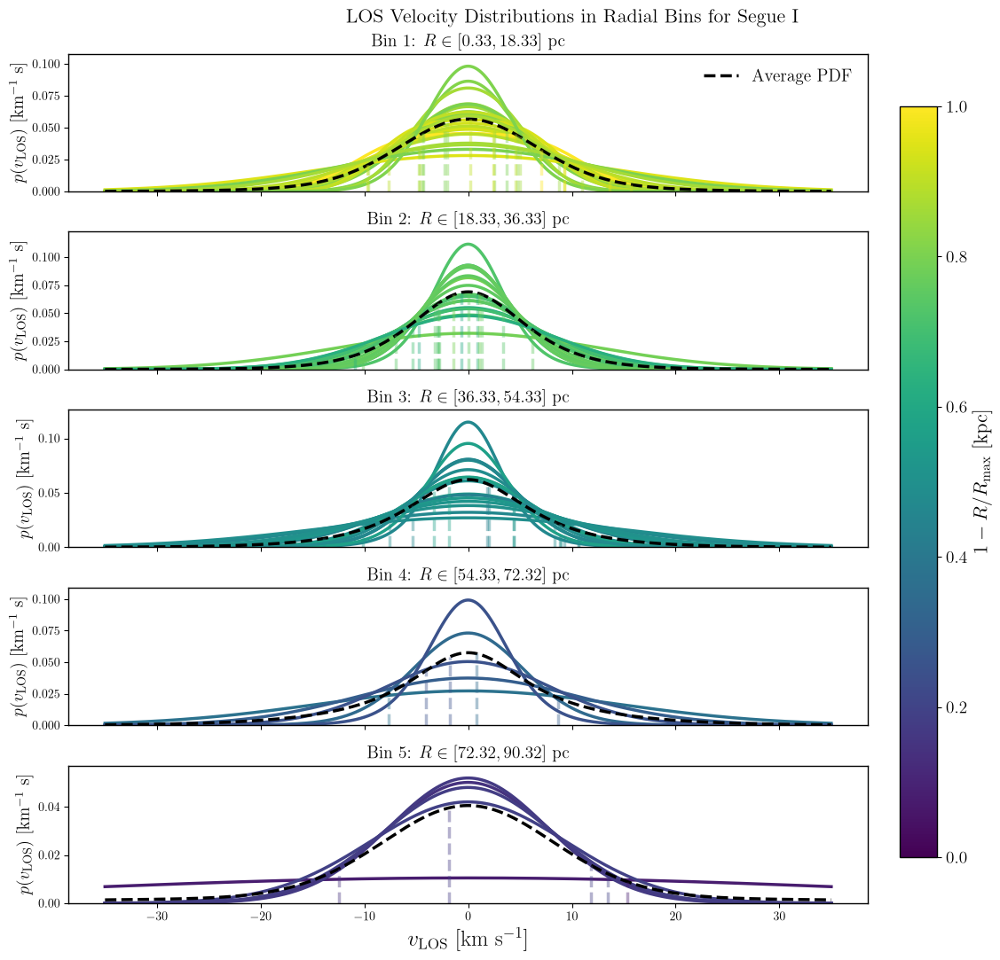

In [28]:
n_bins = 5

rLOS = star_data[:, 0]

bin_edges = np.linspace(rLOS.min(), rLOS.max(), n_bins + 1)

fig, ax = plt.subplots(5, 1, sharex=True, figsize=(13, 11))

for i in range(n_bins):
    mask = (rLOS >= bin_edges[i]) & (rLOS < bin_edges[i + 1])
    bin_rLOS = rLOS[mask]
    bin_vLOS = star_data[mask, 1]
    bin_vLOS_err = star_data[mask, 2]
    sig_at_bin = sig_at[mask]
    kur_at_bin = kur_at[mask]

    vv = np.linspace(-35.0, 35.0, 1000)

    max_pdf = 0.0

    for j, (R, s, k) in enumerate(zip(bin_rLOS, sig_at_bin, kur_at_bin)):
        err = bin_vLOS_err[j]
        ax[i].plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
                   ls='-')

        
        max_pdf = np.max([np.max(fvel(vv, s, k, err)), max_pdf])

    average_pdf = np.mean([fvel(vv, s, k, err) for s, k, err in zip(sig_at_bin, kur_at_bin, bin_vLOS_err)], axis=0)
    ax[i].plot(vv, average_pdf, color='k', lw=2.5, ls='--', label='Average PDF')

    for j in range(len(bin_vLOS)):

        ax[i].vlines(x = bin_vLOS[j], ymax = average_pdf[np.argmin(abs(vv - bin_vLOS[j]))], ymin = 0, color=plt.cm.viridis(1 - bin_rLOS[j]/R_max), lw=2.5, ls='--', alpha = 0.4)

    ax[i].set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=14)
    ax[i].set_title(r'Bin %d: $R \in [%.2f, %.2f]$ pc' % (i + 1, bin_edges[i]*1000, bin_edges[i + 1]*1000), fontsize=14)
    if i == 0:
        ax[i].legend(frameon=False, fontsize=14)

    ax[i].set_ylim(0, max_pdf * 1.1)

ax[-1].set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=18)
fig.suptitle('LOS Velocity Distributions in Radial Bins for Leo II', fontsize=20, x=0.4)
cbar = fig.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', pad = -0.45)

cbar.ax.tick_params(labelsize=14) 
cbar.set_label(r'$1 - R/R_{\max}$ [kpc]', size=16)


ax[-1].set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=18)
fig.suptitle('LOS Velocity Distributions in Radial Bins for Segue I', fontsize=16)
plt.tight_layout()
plt.show()

    



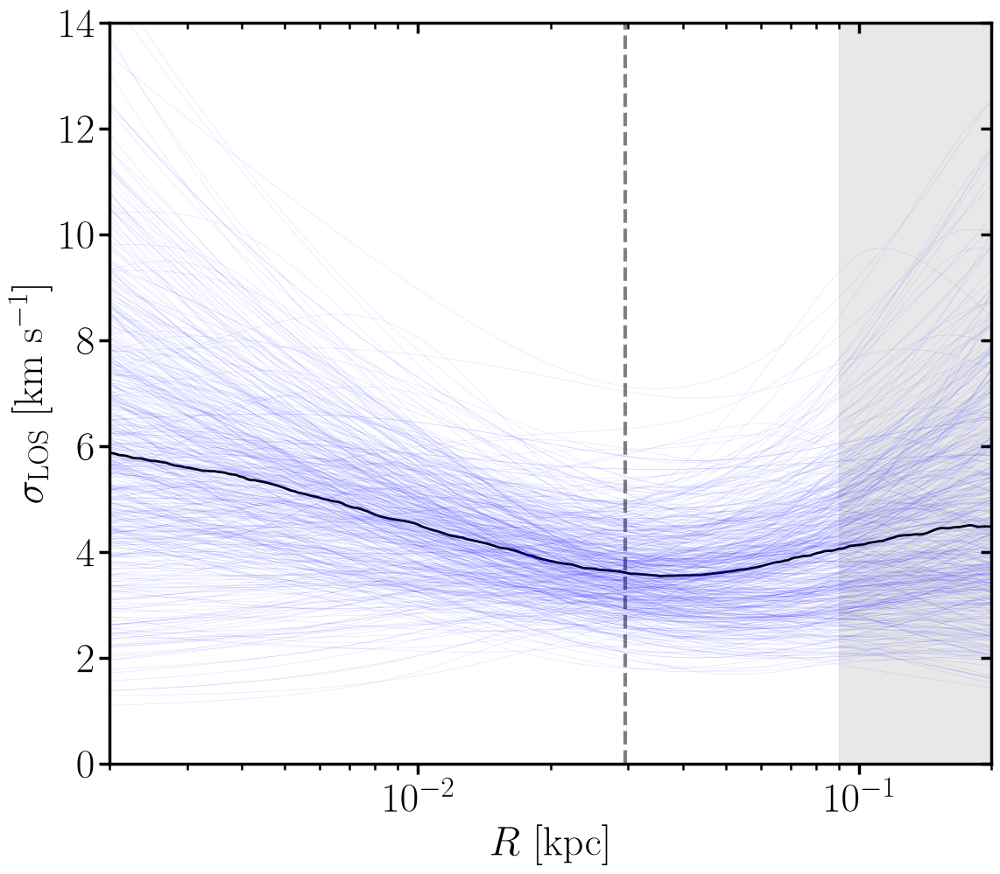

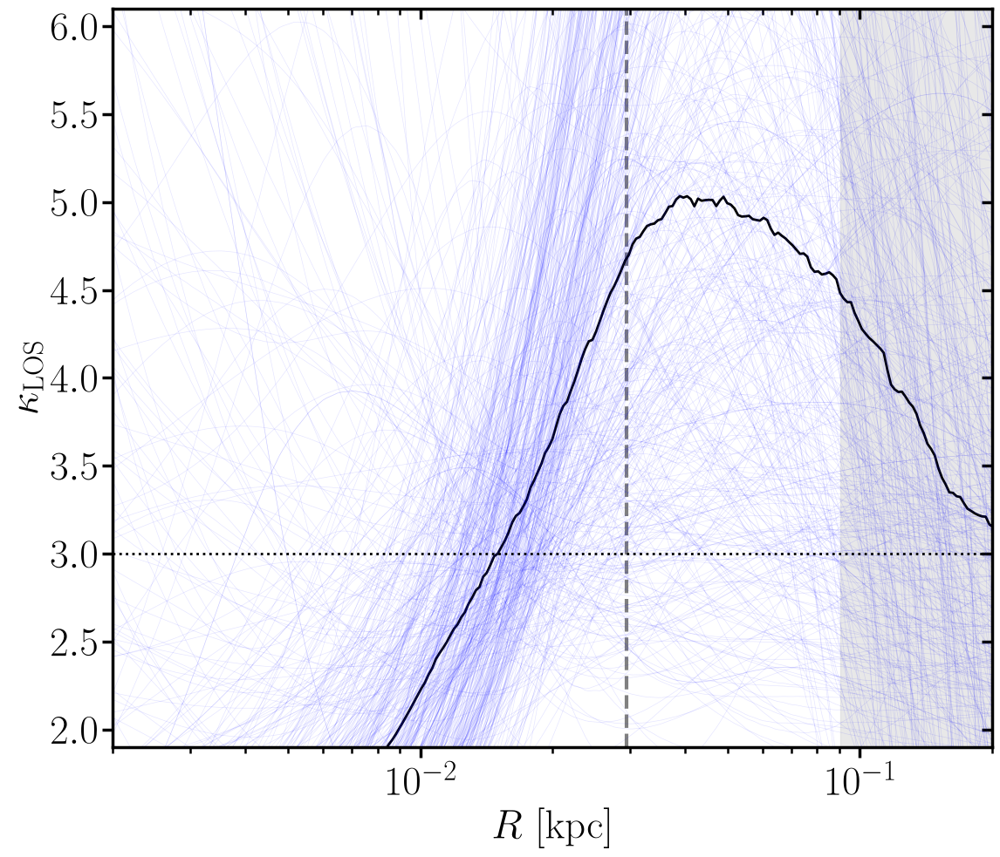

In [ ]:
#--- Segue 1: sigma_LOS and kappa_LOS, with binned data over-plotted --------------------------


#draws from sigma_LOS and kappa_LOS 
plot_draws = 500

# sigma_LOS
b = np.loadtxt(str(diro + s1file + '_sl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))

ax.plot(Ra, b[2], color='k', lw=2.0)
for i in range(plot_draws):
    ax.plot(Ra, upacsl[i], color='blue', lw=0.5, alpha=0.1)

ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
pretty_ax(ax, 0.0, 14.0)
ax.legend(frameon=False, fontsize=fsl*0.6, loc='upper right')
plt.show()

# kappa_LOS
b = np.loadtxt(str(diro + s1file + '_kl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))
ax.plot(Ra, b[2], color='k', lw=2.0)
for i in range(plot_draws):
    ax.plot(Ra, upacslk[i], color='blue', lw=0.5, alpha=0.1)

ax.axhline(3.0, ls=':', color='k', lw=2.0)       # Gaussian
ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\kappa_{\rm LOS}$', fontsize=fsl)
pretty_ax(ax, 1.9, 6.1)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='upper left')
plt.show()

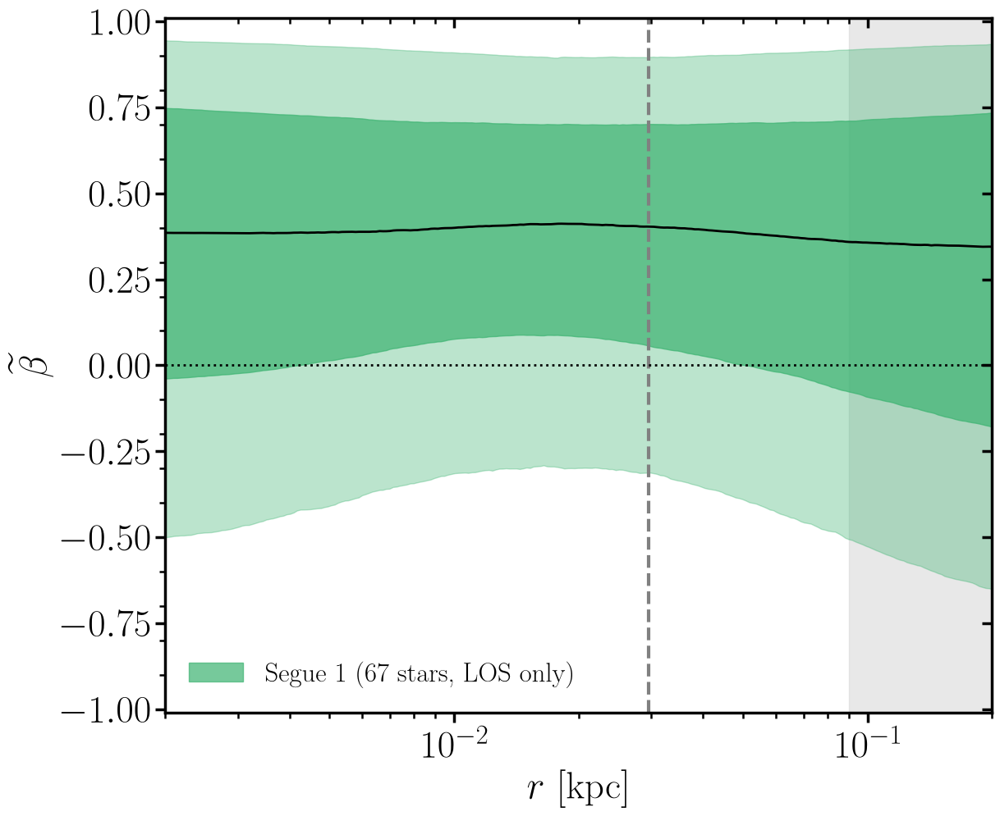

In [ ]:
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.show()




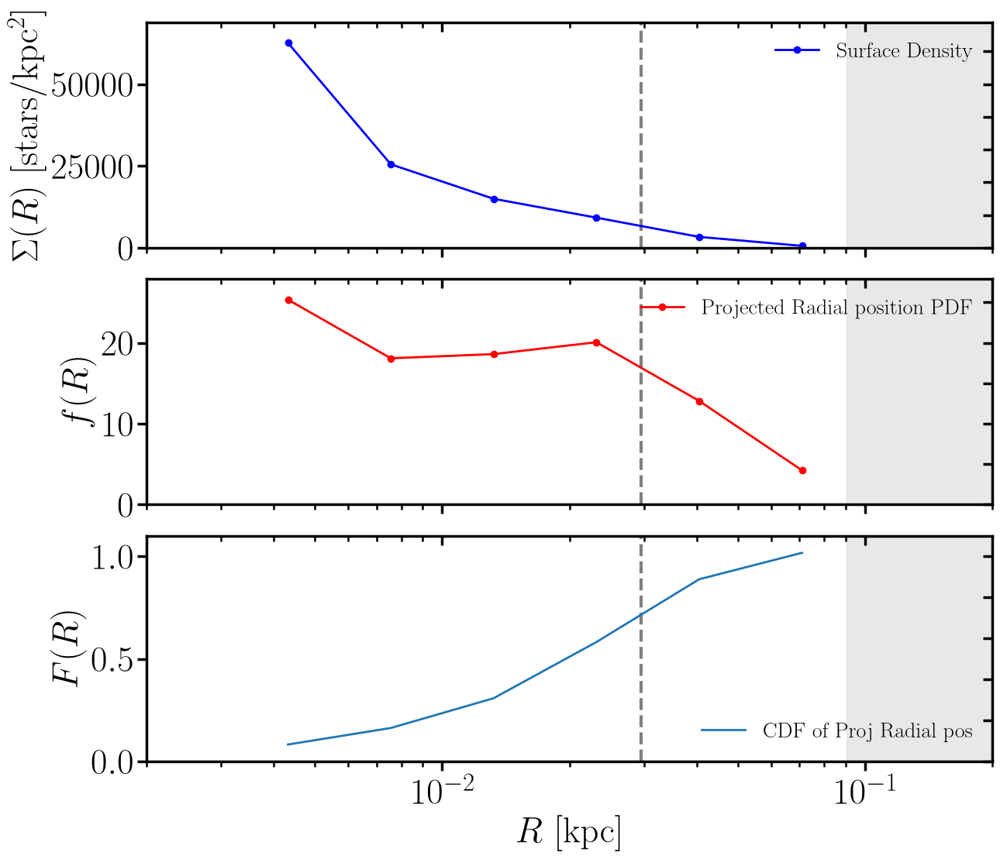

In [65]:
# Plot Sigma(R) (surface density) from data


rLOS = star_data[:, 0]

n_bins = 10
r_bins = np.logspace(np.log10(rLOS.min()), np.log10(rLOS.max()), n_bins + 1)
bin_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

Sigma = np.zeros(n_bins)


for i in range(n_bins):

    mask = (rLOS >= r_bins[i]) & (rLOS < r_bins[i + 1])

    if mask.sum() == 0:
        Sigma[i] = np.nan
        continue

    Sigma[i] = np.sum(mask) / (np.pi * (r_bins[i + 1]**2 - r_bins[i]**2))


fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
ax[0].plot(bin_centers, Sigma, 'o-', color='blue', lw=2.0, label='Surface Density')
ax[0].set_ylabel(r'$\Sigma(R)$ [stars/kpc$^2$]', fontsize=fsl)
pretty_ax(ax[0], 0.0, np.max(Sigma[~np.isnan(Sigma)]) * 1.1)
ax[0].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')


bin_centers = bin_centers[~np.isnan(Sigma)]
Sigma = Sigma[~np.isnan(Sigma)]




f_pos = bin_centers * Sigma / (np.trapezoid(bin_centers * Sigma, bin_centers))
N_stars = len(rLOS)
f_pos = 2 * np.pi * bin_centers * Sigma / N_stars  

ax[1].plot(bin_centers, f_pos, 'o-', color='red', lw=2.0, label='Projected Radial position PDF')
ax[1].set_ylabel(r'$f(R)$', fontsize=fsl)
pretty_ax(ax[1], 0.0, np.max(f_pos) * 1.1)
ax[1].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')


ax[2].plot(bin_centers, np.cumsum(f_pos * np.gradient(bin_centers)), lw = 2, label = 'CDF of Proj Radial pos')
pretty_ax(ax[2], 0.0, 1.1)
ax[2].set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax[2].set_ylabel(r'$F(R)$', fontsize=fsl)
ax[2].legend(frameon=False, fontsize = fsl*0.6, loc='lower right')

plt.tight_layout()
plt.show()

